In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split
print(os.listdir('/content/drive/My Drive'))

['puffinbrowser', 'Classroom', 'IMG_20190809_173354_057 (2).jpg', 'IMG_20190809_173354_057 (1).jpg', 'IMG_20190809_173354_057.jpg', '1596956495-picsay.jpg', '34.Vezan Hidayatullah', 'IMG_20201007_081811.jpg', 'DriveSyncFiles', 'IMG_7445.MOV', 'Screenshot_2021-06-14-15-01-42-1523287264_EDIT_1 (1).png', 'Screenshot_2021-06-14-15-01-42-1523287264_EDIT_1.png', 'Vezan Hidayatullah_121141200434_Teknik Informatika.pdf', 'Struktur.pdf', 'struktur organisasi unila (1).pdf', 'struktur organisasi unila.pdf', 'Resume_Vezan Hidayatullah_S1 Teknik Informatika_Teknik Elektro (1).pdf', 'Resume_Vezan Hidayatullah_S1 Teknik Informatika_Teknik Elektro.pdf', 'Makalah_Vezan Hidayatullah_S1 Teknik Informatika_Teknik.pdf', 'Screenshot_2021-08-28-09-52-03-0960238978.png', 'Screenshot_2021-08-28-09-54-14-1829922455.png', '1234.jpg', 'Vezan Hidayatullah_2115061114_Tanggapan artikel.pdf', 'WhatsApp Image 2021-09-01 at 17.46.24.jpeg', 'KTM.pdf', 'Screenshot_2021-09-06-07-10-06-1063186496.png', 'Artikel pertemuan 

In [ ]:
import tensorflow as tf
from tensorflow.python.client import device_lib

def get_device_info():
    devices = device_lib.list_local_devices()
    return [(device.name, device.device_type) for device in devices]

print(get_device_info())

[('/device:CPU:0', 'CPU')]


In [ ]:
import os
import psutil

def get_system_info():
    cpu_info = os.popen('lscpu').read()
    memory_info = psutil.virtual_memory()
    return cpu_info, memory_info

cpu_info, memory_info = get_system_info()
print("CPU Info:\n", cpu_info)
print("Memory Info:\n", memory_info)

CPU Info:
 Architecture:                         x86_64
CPU op-mode(s):                       32-bit, 64-bit
Address sizes:                        46 bits physical, 48 bits virtual
Byte Order:                           Little Endian
CPU(s):                               2
On-line CPU(s) list:                  0,1
Vendor ID:                            GenuineIntel
Model name:                           Intel(R) Xeon(R) CPU @ 2.20GHz
CPU family:                           6
Model:                                79
Thread(s) per core:                   2
Core(s) per socket:                   1
Socket(s):                            1
Stepping:                             0
BogoMIPS:                             4400.42
Flags:                                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse

In [ ]:
def split_data(source, training, validation, testing, training_size=0.7, validation_size=0.1, testing_size=0.2):
    all_files = []
    for category in os.listdir(source):
        category_path = os.path.join(source, category)
        files = os.listdir(category_path)
        files = [os.path.join(category_path, f) for f in files if os.path.isfile(os.path.join(category_path, f))]
        all_files.extend(files)

    # First split between training and temp files
    training_files, temp_files = train_test_split(all_files, test_size=(1 - training_size))

    # Second split between validation and testing from temp files
    validation_files, testing_files = train_test_split(temp_files, test_size=(testing_size / (validation_size + testing_size)))

    for file in training_files:
        category = os.path.basename(os.path.dirname(file))
        category_path = os.path.join(training, category)
        os.makedirs(category_path, exist_ok=True)
        shutil.copy(file, category_path)

    for file in validation_files:
        category = os.path.basename(os.path.dirname(file))
        category_path = os.path.join(validation, category)
        os.makedirs(category_path, exist_ok=True)
        shutil.copy(file, category_path)

    for file in testing_files:
        category = os.path.basename(os.path.dirname(file))
        category_path = os.path.join(testing, category)
        os.makedirs(category_path, exist_ok=True)
        shutil.copy(file, category_path)

In [ ]:
#Mendifinisikan Path Direktori
drive_path = '/content/drive/My Drive/'
source = os.path.join(drive_path, 'Uvaria')
training = os.path.join(drive_path, 'Uvaria Training')
validation = os.path.join(drive_path, 'Uvaria Validation')
testing = os.path.join(drive_path, 'Uvaria Testing')

#Membuat Direktori
os.makedirs(training, exist_ok=True)
os.makedirs(validation, exist_ok=True)
os.makedirs(testing, exist_ok=True)

In [ ]:
#Split Dataset
split_data(source, training, validation, testing, training_size=0.7, validation_size=0.1, testing_size=0.2)

print(f'Training directories: {os.listdir(training)}')
print(f'Validation directories: {os.listdir(validation)}')
print(f'Tessting directories: {os.listdir(testing)}')

Training directories: ['Uvaria_Batang', 'Uvaria_Pohon', 'Uvaria_Ranting', 'Uvaria_Daun']
Validation directories: ['Uvaria_Batang', 'Uvaria_Daun', 'Uvaria_Ranting', 'Uvaria_Pohon']
Tessting directories: ['Uvaria_Daun', 'Uvaria_Pohon', 'Uvaria_Ranting', 'Uvaria_Batang']


In [ ]:
training_dir = '/content/drive/My Drive/Uvaria Training'
validation_dir = '/content/drive/My Drive/Uvaria Validation'
testing_dir = '/content/drive/My Drive/Uvaria Testing'

In [ ]:
import os

# Path Direktori
dataset_path = training_dir

# Fungsi untuk menghitung jumlah file gambar dalam sebuah direktori
def count_images_in_directory(directory):
    # Daftar ekstensi gambar yang umum
    image_extensions = ('.jpg')
    count = 0
    for root, dirs, files in os.walk(directory):
        # Hitung jumlah file dengan ekstensi gambar yang ada di direktori
        count += len([file for file in files if file.lower().endswith(image_extensions)])
    return count

# Iterasi melalui setiap subdirektori dalam direktori utama
for subdir in os.listdir(dataset_path):
    subdir_path = os.path.join(dataset_path, subdir)
    if os.path.isdir(subdir_path):
        # Hitung gambar di dalam subdirektori
        image_count = count_images_in_directory(subdir_path)
        print(f"{subdir}: {image_count} images")


Uvaria_Daun: 66 images
Uvaria_Batang: 75 images
Uvaria_Ranting: 67 images
Uvaria_Pohon: 71 images


In [ ]:
import os

# Path Direktori
dataset_path = validation_dir

# Fungsi untuk menghitung jumlah file gambar dalam sebuah direktori
def count_images_in_directory(directory):
    # Daftar ekstensi gambar yang umum
    image_extensions = ('.jpg')
    count = 0
    for root, dirs, files in os.walk(directory):
        # Hitung jumlah file dengan ekstensi gambar yang ada di direktori
        count += len([file for file in files if file.lower().endswith(image_extensions)])
    return count

# Iterasi melalui setiap subdirektori dalam direktori utama
for subdir in os.listdir(dataset_path):
    subdir_path = os.path.join(dataset_path, subdir)
    if os.path.isdir(subdir_path):
        # Hitung gambar di dalam subdirektori
        image_count = count_images_in_directory(subdir_path)
        print(f"{subdir}: {image_count} images")

Uvaria_Ranting: 11 images
Uvaria_Daun: 13 images
Uvaria_Pohon: 12 images
Uvaria_Batang: 4 images


In [ ]:
import os

# Path Direktori
dataset_path = testing_dir

# Fungsi untuk menghitung jumlah file gambar dalam sebuah direktori
def count_images_in_directory(directory):
    # Daftar ekstensi gambar yang umum
    image_extensions = ('.jpg')
    count = 0
    for root, dirs, files in os.walk(directory):
        # Hitung jumlah file dengan ekstensi gambar yang ada di direktori
        count += len([file for file in files if file.lower().endswith(image_extensions)])
    return count

# Iterasi melalui setiap subdirektori dalam direktori utama
for subdir in os.listdir(dataset_path):
    subdir_path = os.path.join(dataset_path, subdir)
    if os.path.isdir(subdir_path):
        # Hitung gambar di dalam subdirektori
        image_count = count_images_in_directory(subdir_path)
        print(f"{subdir}: {image_count} images")

Uvaria_Pohon: 17 images
Uvaria_Batang: 21 images
Uvaria_Daun: 21 images
Uvaria_Ranting: 22 images


In [ ]:
import os

def count_files(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

# Menghitung jumlah file di setiap direktori
training_files_count = count_files(training_dir)
validation_files_count = count_files(validation_dir)
testing_files_count = count_files(testing_dir)

# Menghitung total jumlah file dari semua dataset
total_files_count = training_files_count + validation_files_count + testing_files_count

# Mencetak jumlah file untuk setiap dataset serta total keseluruhan
print(f'Total training Dataset: {training_files_count}')
print(f'Total validation Dataset: {validation_files_count}')
print(f'Total testing Dataset: {testing_files_count}')
print(f'Total semua Dataset: {total_files_count}')

Total training Dataset: 279
Total validation Dataset: 40
Total testing Dataset: 81
Total semua Dataset: 400


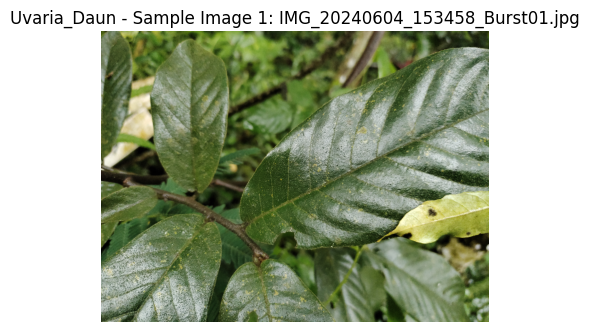

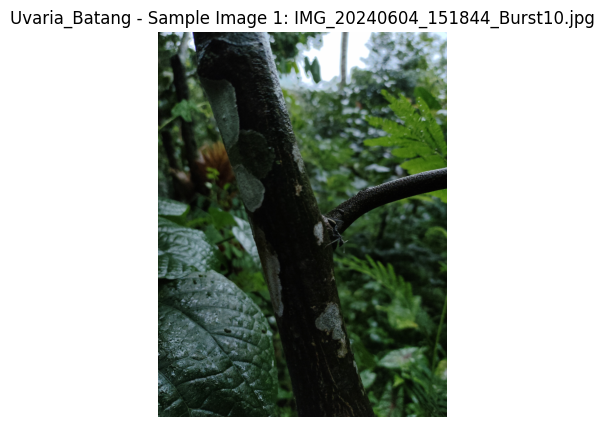

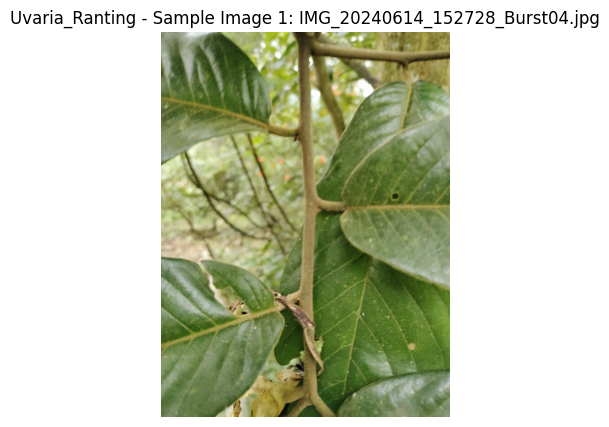

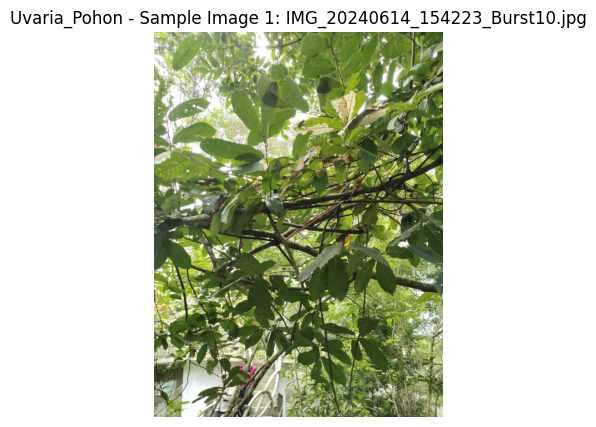

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def display_sample_images_from_subdirectories(parent_directory, num_samples=1):
    # Iterasi melalui setiap subdirektori dalam direktori utama
    for subdir in os.listdir(parent_directory):
        subdir_path = os.path.join(parent_directory, subdir)

        if os.path.isdir(subdir_path):
            # Ambil semua file dari subdirektori
            files = [f for f in os.listdir(subdir_path) if os.path.isfile(os.path.join(subdir_path, f))]

            if files:
                # Pilih beberapa contoh file
                sample_files = files[:num_samples]

                # Tampilkan setiap gambar
                for i, file in enumerate(sample_files):
                    file_path = os.path.join(subdir_path, file)

                    # Bacalah gambar
                    img = mpimg.imread(file_path)

                    # Tampilkan gambar
                    plt.figure(figsize=(5, 5))
                    plt.imshow(img)
                    plt.title(f"{subdir} - Sample Image {i+1}: {file}")
                    plt.axis('off')
                    plt.show()

# Tentukan path ke direktori utama yang berisi subdirektori
training_dir = '/content/drive/My Drive/Uvaria Training'

# Menampilkan contoh gambar dari setiap subdirektori
display_sample_images_from_subdirectories(training_dir, num_samples=1)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255.,
    width_shift_range=0.2,
    height_shift_range=0.2,
    rotation_range=60,
    shear_range=0.3,
    fill_mode='nearest',
    horizontal_flip=True)

validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    training_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 279 images belonging to 4 classes.
Found 40 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Membangun model CNN
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dense(4, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

In [ ]:
# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training the model
batch_size = 32
epochs = 200

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)


Epoch 1/200
8/8 [==============================] - 323s 40s/step - loss: 2.7888 - accuracy: 0.2348 - val_loss: 1.4166 - val_accuracy: 0.0938
Epoch 2/200
8/8 [==============================] - 107s 14s/step - loss: 1.3760 - accuracy: 0.2429 - val_loss: 1.3469 - val_accuracy: 0.3125
Epoch 3/200
8/8 [==============================] - 102s 13s/step - loss: 1.3228 - accuracy: 0.3198 - val_loss: 1.3511 - val_accuracy: 0.2812
Epoch 4/200
8/8 [==============================] - 87s 11s/step - loss: 1.1552 - accuracy: 0.4656 - val_loss: 1.4261 - val_accuracy: 0.4688
Epoch 5/200
8/8 [==============================] - 98s 12s/step - loss: 1.0629 - accuracy: 0.4737 - val_loss: 1.4168 - val_accuracy: 0.3750
Epoch 6/200
8/8 [==============================] - 88s 11s/step - loss: 1.0772 - accuracy: 0.4777 - val_loss: 2.6462 - val_accuracy: 0.3438
Epoch 7/200
8/8 [==============================] - 94s 12s/step - loss: 1.0805 - accuracy: 0.4883 - val_loss: 1.2308 - val_accuracy: 0.4062
Epoch 8/200
8/8 [

In [ ]:
# Evaluate the model
scores = model.evaluate(validation_generator)
print("%s%s: %.2f%%" % ("Evaluating the ",model.metrics_names[1], scores[1]*100))

2/2 [==============================] - 8s 998ms/step - loss: 0.4271 - accuracy: 0.9000
Evaluating the accuracy: 90.00%


In [ ]:
model.save('Uvaria_CNN_200.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


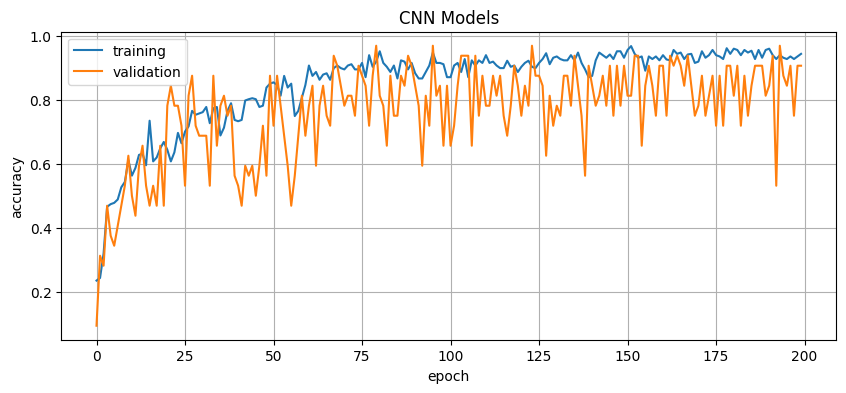

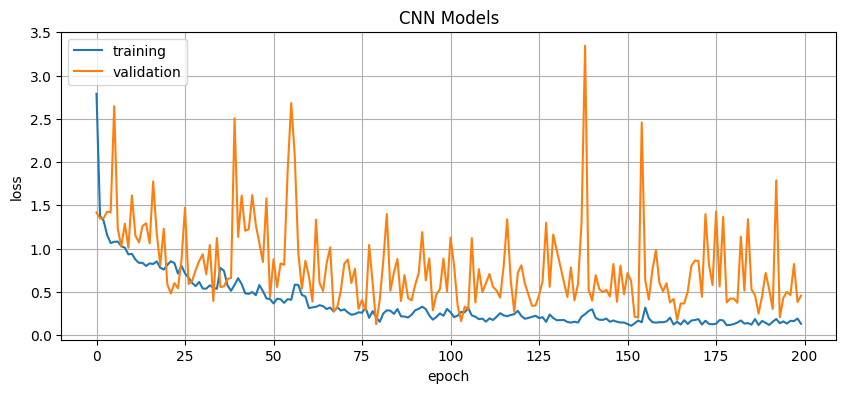

In [ ]:
import matplotlib.pyplot as plt

# Membuat Grafik Akurasi Model CNN
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CNN Models')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='upper left')
plt.grid(True)
plt.show()

print()

# Membuat Grafik Loss Model CNN
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Models')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
# Menampilkan Daftar Pada Label Gambar
train_generator.class_indices

{'Uvaria_Batang': 0, 'Uvaria_Daun': 1, 'Uvaria_Pohon': 2, 'Uvaria_Ranting': 3}

In [ ]:
import os
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Definisikan direktori validasi
testing_dir = '/content/drive/My Drive/Uvaria Testing'

# Definisikan nama kelas
class_names = ['Uvaria_Batang', 'Uvaria_Daun', 'Uvaria_Pohon', 'Uvaria_Ranting']

def predict_images_from_directory(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith(('jpg', 'jpeg', 'png')):
                path = os.path.join(root, file)
                img = load_img(path, target_size=(224, 224))
                x = img_to_array(img)
                x /= 255.0
                x = np.expand_dims(x, axis=0)

                predictions = model.predict(x)
                predicted_class = np.argmax(predictions, axis=1)[0]

                print(f'File: {path}')
                if predicted_class < len(class_names):
                    print(f'Predicted: {class_names[predicted_class]}')
                    print(f'Predicted Class Index: {predicted_class}')
                else:
                    print('Predicted: Tidak Dikenali')

# Panggil fungsi untuk memprediksi gambar dari direktori validasi
predict_images_from_directory(testing_dir)

1/1 [==============================] - 0s 335ms/step
File: /content/drive/My Drive/Uvaria Testing/Uvaria_Pohon/IMG_20240614_153927.jpg
Predicted: Uvaria_Pohon
Predicted Class Index: 2
1/1 [==============================] - 0s 55ms/step
File: /content/drive/My Drive/Uvaria Testing/Uvaria_Pohon/IMG_20240614_153946.jpg
Predicted: Uvaria_Pohon
Predicted Class Index: 2
1/1 [==============================] - 0s 55ms/step
File: /content/drive/My Drive/Uvaria Testing/Uvaria_Pohon/IMG_20240614_154026_Burst06.jpg
Predicted: Uvaria_Pohon
Predicted Class Index: 2
1/1 [==============================] - 0s 57ms/step
File: /content/drive/My Drive/Uvaria Testing/Uvaria_Pohon/IMG_20240614_153953_Burst12.jpg
Predicted: Uvaria_Pohon
Predicted Class Index: 2
1/1 [==============================] - 0s 55ms/step
File: /content/drive/My Drive/Uvaria Testing/Uvaria_Pohon/IMG_20240614_154026_Burst18.jpg
Predicted: Uvaria_Pohon
Predicted Class Index: 2
1/1 [==============================] - 0s 61ms/step
File: /c

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Memuat model dari file H5
model = tf.keras.models.load_model('/content/drive/My Drive/Uvaria_CNN_200ep.h5')

# Konfigurasi data untuk testing
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    testing_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Found 81 images belonging to 4 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 10s/step


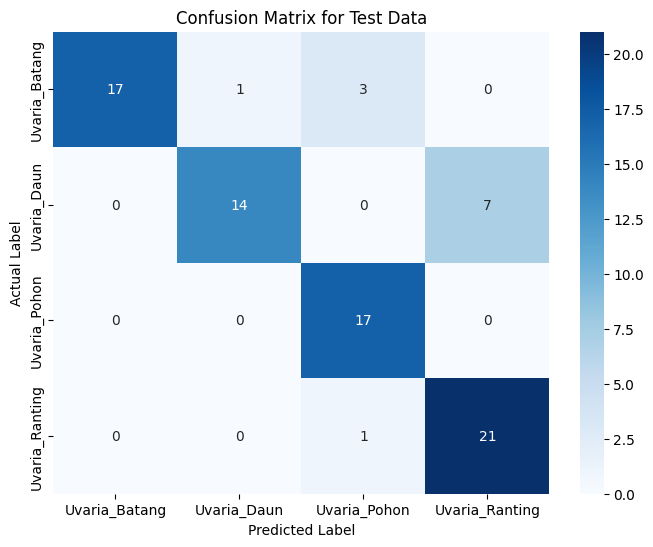

                precision    recall  f1-score   support

 Uvaria_Batang       1.00      0.81      0.89        21
   Uvaria_Daun       0.93      0.67      0.78        21
  Uvaria_Pohon       0.81      1.00      0.89        17
Uvaria_Ranting       0.75      0.95      0.84        22

      accuracy                           0.85        81
     macro avg       0.87      0.86      0.85        81
  weighted avg       0.87      0.85      0.85        81



In [ ]:
# Memprediksi label untuk data testing
test_generator.reset()
Y_test_pred = model.predict(test_generator, test_generator.samples // test_generator.batch_size + 1)
y_test_pred = np.argmax(Y_test_pred, axis=1)
y_test_true = test_generator.classes

# Membuat confusion matrix untuk data testing
cm_test = confusion_matrix(y_test_true, y_test_pred)

# Visualisasi confusion matrix untuk data testing
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt="d", cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Test Data')
plt.show()

# Menampilkan classification report untuk data testing
print(classification_report(y_test_true, y_test_pred, target_names=test_generator.class_indices.keys()))